1. Load data

In [2]:
import pandas as pd

file_path =  "../../data/raw/WESAD/S2/S2_respiban.txt"

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="#",        # ignores JSON header + metadata
    header=None,
    engine="python"
)

print(data.shape)
print(data.head())

(4442067, 11)
   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN


The blue (Raw ECG) is shifted upward by a large constant value (DC offset).
The orange (Filtered ECG) is centered around 0 because the bandpass filter removed the DC offset.

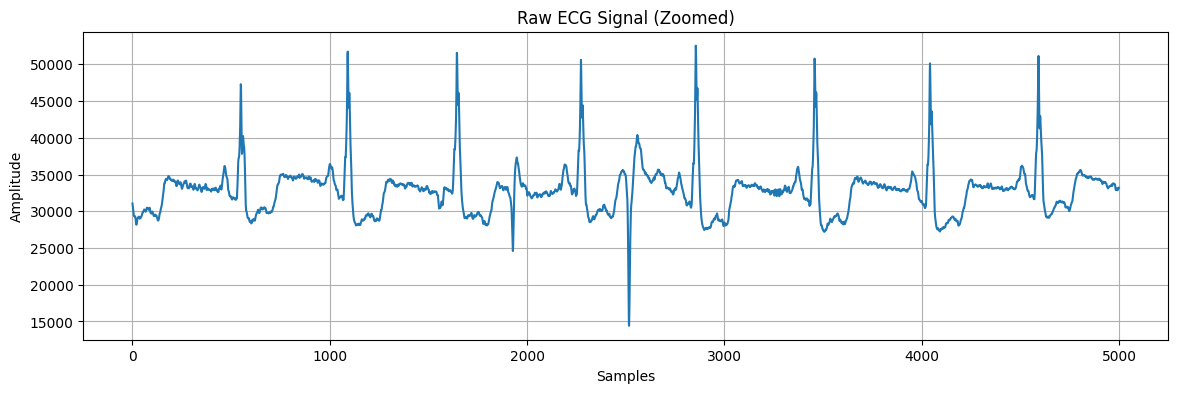

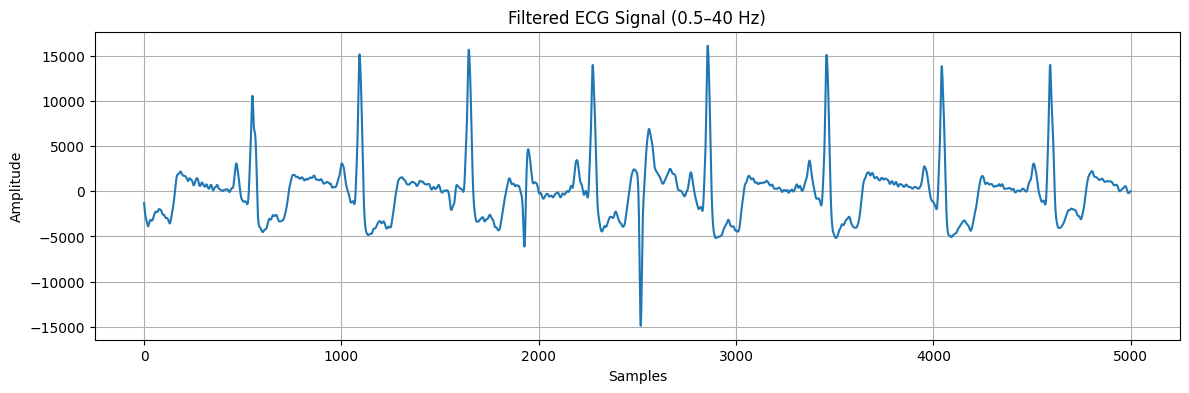

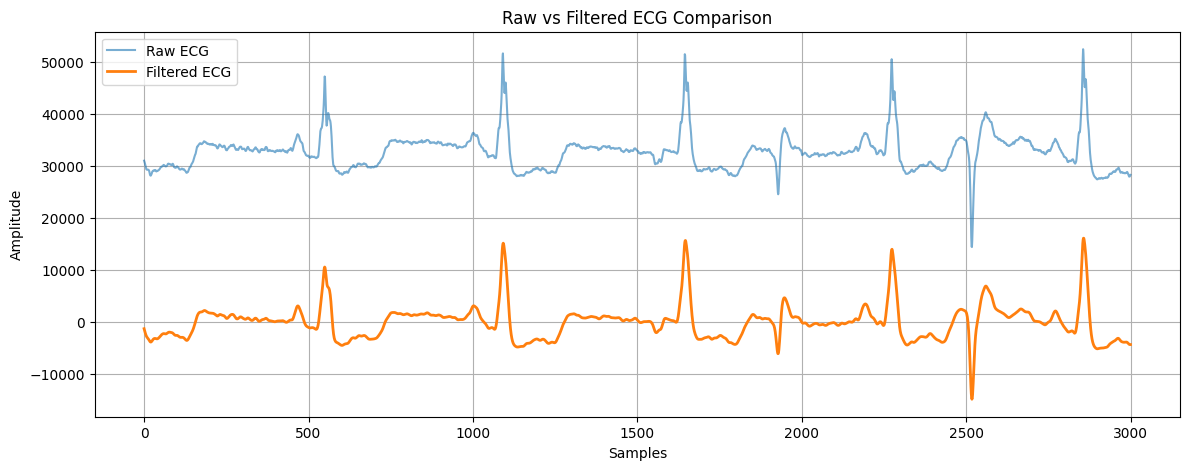

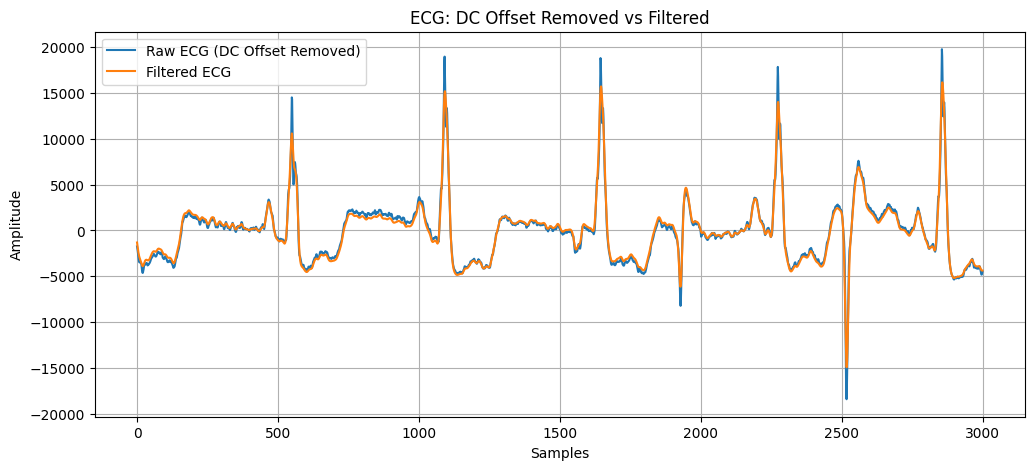

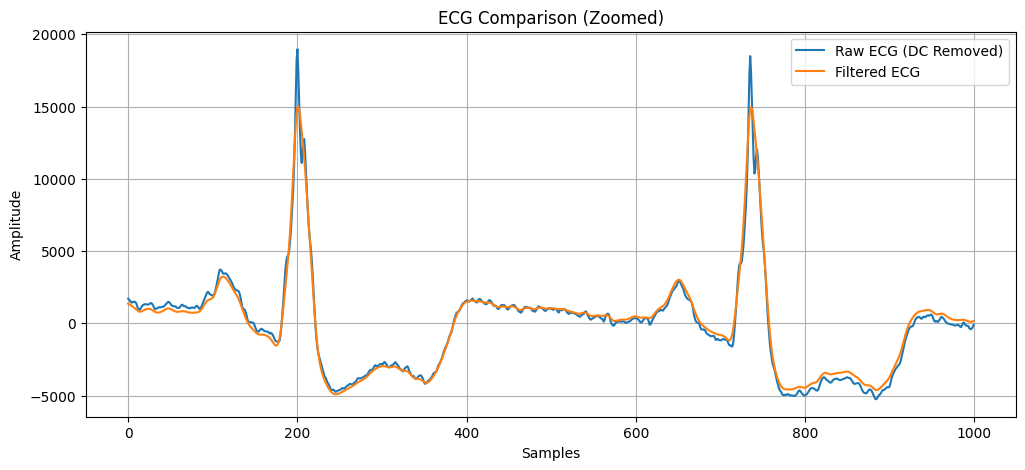

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# -----------------------------
# STEP 1: Extract ECG
# -----------------------------
ecg = data.iloc[:, 2].values   # CH1 as ECG (change if needed)

# -----------------------------
# STEP 2: Bandpass Filter (0.5–40 Hz)
# -----------------------------
def bandpass_filter(signal, fs=700, low=0.5, high=40, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

ecg_filtered = bandpass_filter(ecg)

# -----------------------------
# STEP 3: Plot RAW ECG
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(ecg[:5000])
plt.title("Raw ECG Signal (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -----------------------------
# STEP 4: Plot FILTERED ECG
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(ecg_filtered[:5000])
plt.title("Filtered ECG Signal (0.5–40 Hz)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -----------------------------
# STEP 5: COMPARISON PLOT
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(ecg[:3000], label="Raw ECG", alpha=0.6)
plt.plot(ecg_filtered[:3000], label="Filtered ECG", linewidth=2)
plt.title("Raw vs Filtered ECG Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

ecg_centered = ecg - np.mean(ecg)  #dc offset removal
import matplotlib.pyplot as plt

n_samples = 3000

plt.figure(figsize=(12,5))

plt.plot(ecg_centered[:n_samples], label="Raw ECG (DC Offset Removed)")
plt.plot(ecg_filtered[:n_samples], label="Filtered ECG")

plt.title("ECG: DC Offset Removed vs Filtered")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()
start = 10000
n_samples = 1000

plt.figure(figsize=(12,5))

plt.plot(ecg_centered[start:start+n_samples], label="Raw ECG (DC Removed)")
plt.plot(ecg_filtered[start:start+n_samples], label="Filtered ECG")

plt.title("ECG Comparison (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

Quality Metrics

In [5]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# ----------------------------
# Remove DC Offset
# ----------------------------
ecg_centered = ecg - np.mean(ecg)

# ----------------------------
# Mean
# ----------------------------
ecg_mean_raw = np.mean(ecg)
ecg_mean_filtered = np.mean(ecg_filtered)
ecg_mean_centered = np.mean(ecg_centered)

# ----------------------------
# Standard Deviation
# ----------------------------
ecg_std_raw = np.std(ecg)
ecg_std_filtered = np.std(ecg_filtered)
ecg_std_centered = np.std(ecg_centered)

# ----------------------------
# Noise Estimate
# ----------------------------
ecg_noise_raw = np.std(np.diff(ecg))
ecg_noise_filtered = np.std(np.diff(ecg_filtered))
ecg_noise_centered = np.std(np.diff(ecg_centered))

# ----------------------------
# Baseline Drift
# ----------------------------
window = 7000

ecg_drift_raw = np.std(
    np.convolve(ecg, np.ones(window)/window, mode='same')
)

ecg_drift_filtered = np.std(
    np.convolve(ecg_filtered,
                np.ones(window)/window,
                mode='same')
)

ecg_drift_centered = np.std(
    np.convolve(ecg_centered,
                np.ones(window)/window,
                mode='same')
)

# ----------------------------
# Outlier Count (>3σ)
# ----------------------------
z_raw = np.abs((ecg - ecg_mean_raw) / ecg_std_raw)
z_filtered = np.abs((ecg_filtered - ecg_mean_filtered) / ecg_std_filtered)
z_centered = np.abs((ecg_centered - ecg_mean_centered) / ecg_std_centered)

outliers_raw = np.sum(z_raw > 3)
outliers_filtered = np.sum(z_filtered > 3)
outliers_centered = np.sum(z_centered > 3)

# ----------------------------
# R Peak Detection
# ----------------------------
fs = 700

peaks_raw, _ = find_peaks(
    ecg_centered,
    distance=0.4*fs,
    prominence=np.std(ecg_centered)
)

peaks_filtered, _ = find_peaks(
    ecg_filtered,
    distance=0.4*fs,
    prominence=np.std(ecg_filtered)
)

# ----------------------------
# RR Interval
# ----------------------------
rr_raw = np.diff(peaks_raw) / fs
rr_filtered = np.diff(peaks_filtered) / fs

rr_mean_raw = np.mean(rr_raw)
rr_mean_filtered = np.mean(rr_filtered)

rr_std_raw = np.std(rr_raw)
rr_std_filtered = np.std(rr_filtered)

# ----------------------------
# Heart Rate
# ----------------------------
hr_raw = 60 / rr_raw
hr_filtered = 60 / rr_filtered

hr_mean_raw = np.mean(hr_raw)
hr_mean_filtered = np.mean(hr_filtered)

hr_std_raw = np.std(hr_raw)
hr_std_filtered = np.std(hr_filtered)

# ----------------------------
# Results Table
# ----------------------------
results = pd.DataFrame({

    "Metric":[
        "Mean",
        "Std",
        "Noise Estimate",
        "Baseline Drift",
        "Outliers (>3σ)",
        "R Peak Count",
        "Mean RR Interval (s)",
        "RR Interval Std (s)",
        "Mean Heart Rate (BPM)",
        "Heart Rate Std (BPM)"
    ],

    "Raw":[
        ecg_mean_raw,
        ecg_std_raw,
        ecg_noise_raw,
        ecg_drift_raw,
        outliers_raw,
        len(peaks_raw),
        rr_mean_raw,
        rr_std_raw,
        hr_mean_raw,
        hr_std_raw
    ],

    "Filtered":[
        ecg_mean_filtered,
        ecg_std_filtered,
        ecg_noise_filtered,
        ecg_drift_filtered,
        outliers_filtered,
        len(peaks_filtered),
        rr_mean_filtered,
        rr_std_filtered,
        hr_mean_filtered,
        hr_std_filtered
    ],

    "DC Offset Removed":[
        ecg_mean_centered,
        ecg_std_centered,
        ecg_noise_centered,
        ecg_drift_centered,
        outliers_centered,
        len(peaks_raw),
        rr_mean_raw,
        rr_std_raw,
        hr_mean_raw,
        hr_std_raw
    ]

})

print(results)

                  Metric            Raw       Filtered  DC Offset Removed
0                   Mean   32794.480049      -0.042806       1.163716e-12
1                    Std    3381.455146    3284.187758       3.381455e+03
2         Noise Estimate     345.338699     221.839470       3.453387e+02
3         Baseline Drift     379.484095      32.310694       5.542104e+01
4         Outliers (>3σ)  107043.000000  114692.000000       1.070430e+05
5           R Peak Count    7726.000000    7716.000000       7.726000e+03
6   Mean RR Interval (s)       0.821357       0.822422       8.213570e-01
7    RR Interval Std (s)       0.116635       0.115295       1.166348e-01
8  Mean Heart Rate (BPM)      74.932904      74.764324       7.493290e+01
9   Heart Rate Std (BPM)      13.871643      13.484588       1.387164e+01


| **Metric**                         | **DC Offset Removed** | **Filtered** |           **Change** | **Conclusion**                                                                                                                                                         |
| ---------------------------------- | --------------------: | -----------: | -------------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Mean**                           |                   ≈ 0 |       -0.043 |           Negligible | Both signals are centered around zero, indicating that the DC offset has been successfully removed.                                                                    |
| **Standard Deviation**             |               3381.46 |      3284.19 |  **2.88% reduction** | The filter slightly reduces overall signal variability by removing unwanted frequency components while preserving the ECG waveform.                                    |
| **Noise Estimate**                 |                345.34 |       221.84 | **35.76% reduction** | The filter significantly reduces random and high-frequency noise, producing a cleaner ECG signal.                                                                      |
| **Baseline Drift**                 |                 55.42 |        32.31 | **41.70% reduction** | After DC offset removal, the filter further suppresses the remaining slow-varying baseline wander, resulting in a more stable baseline.                                |
| **Outliers (>3σ)**                 |               107,043 |      114,692 |   **7.15% increase** | The increase is expected because filtering enhances the QRS complexes, causing more samples to exceed the ±3σ threshold. This does not indicate poorer signal quality. |
| **R Peak Count**                   |                  7726 |         7716 |   **0.13% decrease** | The filter preserves nearly all R-peaks, indicating that the essential cardiac information is retained.                                                                |
| **Mean RR Interval**               |              0.8214 s |     0.8224 s |   **0.13% increase** | The average heartbeat interval remains almost unchanged, demonstrating that the filter preserves cardiac timing.                                                       |
| **RR Interval Standard Deviation** |              0.1166 s |     0.1153 s |  **1.15% reduction** | The slight reduction indicates a more consistent estimation of beat-to-beat intervals after filtering.                                                                 |
| **Mean Heart Rate**                |             74.93 BPM |    74.76 BPM |   **0.23% decrease** | The average heart rate remains virtually unchanged, confirming that filtering does not alter the physiological heart rate.                                             |
| **Heart Rate Standard Deviation**  |             13.87 BPM |    13.48 BPM |  **2.79% reduction** | The reduced variability indicates a more stable heart rate estimation due to improved signal quality.                                                                  |


Overall Conclusion

After removing the DC offset, the ECG signal is already centered around zero. The bandpass filter provides additional improvements by:

Reducing signal variability by 2.88%.
Reducing high-frequency noise by 35.76%, producing a cleaner ECG.
Further reducing baseline drift by 41.70%, resulting in a more stable baseline.
Preserving more than 99.8% of the R-peaks, ensuring that the physiological information remains intact.
Maintaining RR intervals and heart rate, with changes of less than 0.3%, indicating that the filter enhances signal quality without distorting the underlying cardiac activity.

This comparison clearly demonstrates that DC offset removal only recenters the ECG signal, whereas the bandpass filter further improves the signal by suppressing noise and baseline drift while preserving clinically relevant ECG features